# Task 0 

In [7]:
import gzip
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import BPR
from recbole.trainer import Trainer

In [20]:
import os
import torch
import json
import pandas as pd
from datetime import datetime

# Globalny słownik na wszystkie wyniki
final_archive = {
    'models': {},
    'configs': {},
    'results': {},
    'plots': {}
}

# Folder główny z timestampem
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_dir = os.path.join('output', f'full_experiment_{timestamp}')
os.makedirs(output_dir, exist_ok=True)

In [8]:
data = []

with gzip.open('All_Beauty.jsonl.gz', 'rt', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        
        user = item.get('reviewerID') or item.get('user_id')
        item_id = item.get('asin') or item.get('parent_asin')
        rating = item.get('overall') or item.get('rating')
        timestamp = item.get('unixReviewTime') or item.get('timestamp')
        
        if user and item_id and rating and timestamp:
            data.append([
                str(user), 
                str(item_id), 
                float(rating), 
                int(timestamp)
            ])

df = pd.DataFrame(data, columns=['user_id:token', 'item_id:token', 'rating:float', 'timestamp:float'])

os.makedirs('./dataset/Amazon_Beauty', exist_ok=True)
df.to_csv('./dataset/Amazon_Beauty/Amazon_Beauty.inter', sep='\t', index=False)
print(f"Dane gotowe. Liczba interakcji: {len(df)}")

Dane gotowe. Liczba interakcji: 701528


In [12]:
# Konfiguracja modelu

config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',     
    'model': 'BPR',               
    'epochs': 2,                 
    'train_batch_size': 2048,
    'eval_batch_size': 4096,
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]},  # Losowy podział: 80% trening, 10% walidacja, 10% test
        'group_by': 'user',                # Ewaluacja na poziomie użytkownika
        'order': 'RO',                     # Random Order (kolejność nie ma znaczenia w tym modelu)
        'mode': 'full'                     # Porównujemy z każdym możliwym przedmiotem
    },
    'save_dataset': False,                 
    'device': 'cpu'
}

config = Config(model='BPR', dataset='Amazon_Beauty', config_dict=config_dict)

In [13]:
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu BPR...")
model = BPR(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True)

/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)


Trenowanie modelu BPR...


Evaluate   : 100%|█████████████████████████████████████████████| 9159/9159 [00:14<00:00, 630.02it/s]


(0.0476,
 OrderedDict([('recall@10', 0.0596),
              ('mrr@10', 0.0476),
              ('ndcg@10', 0.0504),
              ('hit@10', 0.0599),
              ('precision@10', 0.006)]))

In [14]:
loss_dict = trainer.train_loss_dict
test_result = trainer.evaluate(test_data, show_progress=True)

Evaluate   : 100%|███████████████████████████████████████████| 48433/48433 [01:33<00:00, 519.90it/s]


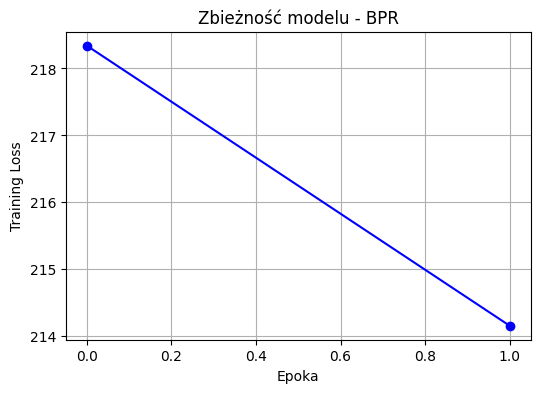


TESTY BPR:
   recall@10  mrr@10  ndcg@10  hit@10  precision@10
0     0.0593  0.0376   0.0428  0.0594         0.006


In [15]:
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - BPR')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"\nTESTY BPR:\n{pd.DataFrame([test_result])}")

# Task 1

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.sequential_recommender import SASRec
from recbole.trainer import Trainer
from recbole.utils.case_study import full_sort_topk

In [18]:
# KONFIGURACJA MODELU SEKWENCYJNEGO (SASRec)

config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',
    'model': 'SASRec',
    
    # model sekwencyjny musi mieć czas
    'load_col': {'inter': ['user_id', 'item_id', 'timestamp']},
    'USER_ID_FIELD': 'user_id',
    'ITEM_ID_FIELD': 'item_id',
    'TIME_FIELD': 'timestamp',
    'MAX_ITEM_LIST_LENGTH': 50,    
    
    'epochs': 20,                  
    'train_batch_size': 512,       
    'eval_batch_size': 512,
    'train_neg_sample_args': None, # Wymagane przy tym modelu
    
    # Zgodnie z poleceniem: chronologiczny podział Leave-One-Out
    'eval_args': {
        'split': {'LS': 'valid_and_test'}, 
        'group_by': 'user',
        'order': 'TO', # TO = Time Order 
        'mode': 'full'                     
    },
    
    'topk': [5, 10, 20],
    'metrics': ['Recall', 'NDCG'],
    'valid_metric': 'NDCG@10',
    'save_dataset': False ,
    'device': 'cpu'
}

config = Config(model='SASRec', dataset='Amazon_Beauty', config_dict=config_dict)

In [21]:
print("Ładowanie danych i podział chronologiczny...")
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu SASRec (sieć atencyjna)...")
model = SASRec(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True) 

print("Ewaluacja ogólna na zbiorze testowym...")
test_result = trainer.evaluate(test_data, load_best_model=True, show_progress=True)

test_result = pd.DataFrame([test_result])


Ładowanie danych i podział chronologiczny...


/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)
/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:650: ChainedAssignme

Trenowanie modelu SASRec (sieć atencyjna)...


Evaluate   : 100%|████████████████████████████████████████████████████| 7/7 [00:02<00:00,  3.47it/s]


Ewaluacja ogólna na zbiorze testowym...


Evaluate   : 100%|██████████████████████████████████████████████████| 18/18 [00:05<00:00,  3.25it/s]


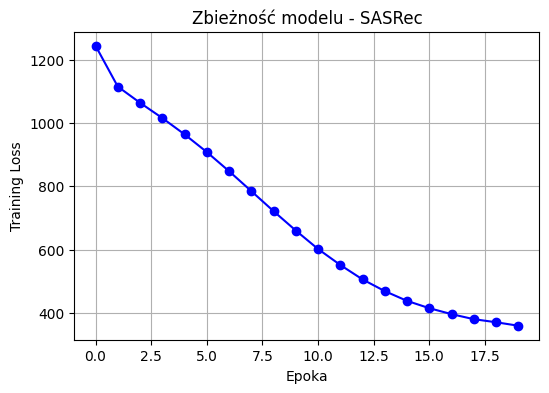

WYNIKI OGÓLNE SASRec
   recall@5  recall@10  recall@20  ndcg@5  ndcg@10  ndcg@20
0    0.1174     0.1239     0.1334  0.1071   0.1092   0.1117


In [22]:
loss_dict = trainer.train_loss_dict
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - SASRec')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"WYNIKI OGÓLNE SASRec\n{test_result}")

In [23]:
# Wyciągamy liczbę zakupów każdego użytkownika
user_counts = pd.Series(dataset.inter_feat['user_id'].numpy()).value_counts()

# Wyciągamy testowych użytkowników i to, co naprawdę kupili
test_users, target_items = [], []
for batch in test_data:
    test_users.extend(batch[0]['user_id'].numpy())
    target_items.extend(batch[3].numpy()) 
test_users, target_items = np.array(test_users), np.array(target_items)

# Generujemy predykcje Top-20 dla wszystkich
_, topk_iid = full_sort_topk(uid_series=test_users, model=model, test_data=test_data, k=20, device=config['device'])
topk_iid = topk_iid.cpu().numpy()

# Funkcja wyliczająca metryki dla każdego użytkownika z osobna
def get_user_metrics(preds, targets, k):
    hits = (preds[:, :k] == targets[:, None])
    recall = hits.sum(axis=1)
    ndcg = np.zeros(len(targets))
    rows, cols = np.where(hits)
    ndcg[rows] = 1.0 / np.log2(cols + 2)
    return recall, ndcg

# Tworzymy tabelę z wynikami
df = pd.DataFrame({'user_id': test_users, 'hist_len': user_counts.loc[test_users].values})
for k in [5, 10, 20]:
    df[f'Recall@{k}'], df[f'NDCG@{k}'] = get_user_metrics(topk_iid, target_items, k)

# Dzielimy na koszyki z polecenia
bins = [0, 5, 10, 15, 20, 30, 9999]
labels = ['1-5', '6-10', '11-15', '16-20', '21-30', '30+']
df['group'] = pd.cut(df['hist_len'], bins=bins, labels=labels, right=True)

# Agregujemy do tabeli końcowej
stats = df.groupby('group', observed=False).agg(
    user_count=('user_id', 'count'),
    **{m: (m, 'mean') for m in ['Recall@10', 'NDCG@10', 'Recall@20', 'NDCG@20']}
)

print("ANALIZA W GRUPACH DŁUGOŚCI SEKWENCJI")
print(stats)


ANALIZA W GRUPACH DŁUGOŚCI SEKWENCJI
       user_count  Recall@10   NDCG@10  Recall@20   NDCG@20
group                                                      
1-5          8448   0.127841  0.113692   0.136955  0.116010
6-10          451   0.079823  0.061719   0.093126  0.065195
11-15         118   0.059322  0.041676   0.093220  0.050401
16-20          41   0.048780  0.014684   0.048780  0.014684
21-30          56   0.107143  0.069362   0.107143  0.069362
30+            45   0.088889  0.060705   0.088889  0.060705


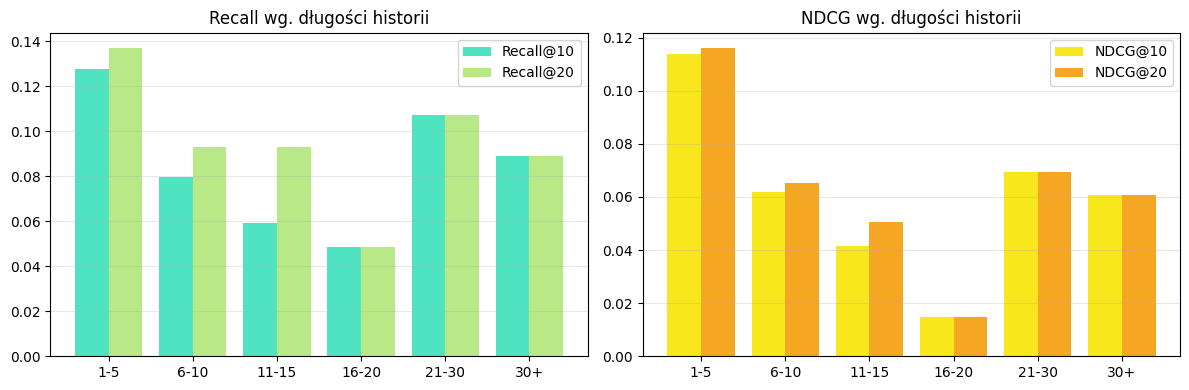

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(stats.index))

axes[0].bar(x - 0.2, stats['Recall@10'].fillna(0), 0.4, label='Recall@10', color='#50E3C2')
axes[0].bar(x + 0.2, stats['Recall@20'].fillna(0), 0.4, label='Recall@20', color='#B8E986')
axes[0].set(title='Recall wg. długości historii', xticks=x, xticklabels=stats.index)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - 0.2, stats['NDCG@10'].fillna(0), 0.4, label='NDCG@10', color='#F8E71C')
axes[1].bar(x + 0.2, stats['NDCG@20'].fillna(0), 0.4, label='NDCG@20', color='#F5A623')
axes[1].set(title='NDCG wg. długości historii', xticks=x, xticklabels=stats.index)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Jak działa model SASRec i na czym polega sekwencyjność?
Tradycyjne modele (jak BPR z Task 0) traktują historię użytkownika jak "worek produktów" – nie obchodzi ich, czy najpierw kupiłeś szampon, a potem odżywkę, czy odwrotnie.

SASRec (Self-Attentive Sequential Recommendation) działa inaczej:

* Kolejność ma znaczenie: Model widzi historię jako ciąg zdarzeń w czasie - wykorzystuje transformer.

* Mechanizm Atencji: Model analizuje wszystkie Twoje poprzednie zakupy i decyduje, które z nich są najważniejsze dla przewidzenia następnego kroku.

* Przykład: Jeśli kupiłeś 5 różnych rzeczy, ale ostatnie dwie to lakier do paznokci i zmywacz, mechanizm atencji "zaświeci się" mocniej przy tych dwóch produktach, ignorując np. krem do stóp kupiony rok temu, by zaproponować Ci pilniczek.

Wyjaśnienie metryk (Recall i NDCG)
W systemach rekomendacyjnych nie oceniamy modelu prosto "dobrze/źle", bo rzadko trafiamy idealnie w jeden produkt. Oceniamy listę Top-K (u nas Top 5, 10, 20).

Recall@K (czułość): Odpowiada na pytanie: "Czy ten jeden produkt, który użytkownik naprawdę kupił, znalazł się gdziekolwiek na liście K propozycji, którą mu daliśmy?".

Jeśli użytkownik kupił produkt X, a nasz model dał go na 9. miejscu w Top-10, to Recall@10 = 1. Jeśli dał go na 11. miejscu, Recall@10 = 0.

NDCG@K (Normalized Discounted Cumulative Gain): To metryka "jakości sortowania". Jest surowsza niż Recall. Premiuje model za trafienia na samej górze listy.

Jeśli trafiony produkt jest na 1. miejscu, NDCG jest wysokie (bliskie 1).

Jeśli trafiony produkt jest na 10. miejscu, NDCG będzie znacznie niższe.

To kluczowe w e-commerce – klienci rzadko przewijają stronę w dół, więc im wyżej trafienie, tym lepiej.

### Zadanie 1 - Wnioski i Analiza Sekwencji (SASRec)

**1. Trening i Ewaluacja:**
Ogólne wyniki dla całego zbioru testowego (Recall@20 = 0.1334, NDCG@20 = 0.1117) 

**2. Skuteczność a Długość Historii (Sequence Length):**
Podział użytkowników na koszyki względem długości ich historii zakupowej ujawnia bardzo ciekawy, nieoczywisty trend na wykresach słupkowych:
* **Wysoka skuteczność dla nowych:** Model radzi sobie zdecydowanie najlepiej dla użytkowników o najkrótszej historii (1-5 interakcji), gdzie metryki osiągają szczytowe wartości (NDCG > 0.11).
* **Zapaść w "środku":** Wraz ze wzrostem długości historii, jakość rekomendacji nieoczekiwanie i drastycznie spada, osiągając absolutne minimum dla grupy 16-20 interakcji (NDCG spada poniżej 0.02).
* **Lekkie odbicie dla najdłuższych:** Dla bardzo długich sekwencji (21-30 oraz 30+) skuteczność delikatnie odbija w górę, jednak nie wraca już do poziomu bazowego z pierwszej grupy.

**3. Wnioski (Interpretacja):**
Choć teoretycznie model Transformer (SASRec) powinien zyskiwać dzięki posiadaniu dłuższego kontekstu historycznego, wyniki pokazują coś odwrotnego. Wynika to z natury ludzkich zachowań w e-commerce. Użytkownicy z najkrótszą historią (1-5) mają bardzo powtarzalne, przewidywalne ścieżki (najczęściej kupują popularne bestsellery). Natomiast mocno zaangażowani klienci (16-20 zakupów) mocniej eksplorują produkty niszowe z tzw. "długiego ogona". Ich gusta są dużo bardziej zróżnicowane i specyficzne, co czyni przewidzenie ich dokładnego, kolejnego kroku znacznie trudniejszym dla modelu.

# Task 2

In [9]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.general_recommender import LightGCN
from recbole.trainer import Trainer
from recbole.utils.case_study import full_sort_topk

In [2]:
config_dict = {
    'dataset': 'Amazon_Beauty',
    'data_path': './dataset',
    'model': 'LightGCN',
    'epochs': 20,
    'train_batch_size': 2048,
    'eval_batch_size': 4096,
    
    # Podział losowy (LightGCN nie patrzy na czas, tylko na powiązania)
    'eval_args': {
        'split': {'RS': [0.8, 0.1, 0.1]}, 
        'group_by': 'user',
        'order': 'RO',
        'mode': 'full'
    },
    'topk': [5, 10, 20],
    'metrics': ['Recall', 'NDCG'],
    'valid_metric': 'NDCG@10',
    'save_dataset': False,
    'device': 'cpu'
}

config = Config(model='LightGCN', dataset='Amazon_Beauty', config_dict=config_dict)

In [3]:
print("Ładowanie danych i tworzenie grafu (LightGCN)...")
dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

print("Trenowanie modelu...")
model = LightGCN(config, train_data.dataset).to(config['device'])
trainer = Trainer(config, model)
trainer.fit(train_data, valid_data, show_progress=True)

print("Ewaluacja ogólna na zbiorze testowym...")
test_result = trainer.evaluate(test_data, load_best_model=True)
test_result = pd.DataFrame([test_result])

Ładowanie danych i tworzenie grafu (LightGCN)...


/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:648: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  feat[field].fillna(value=0, inplace=True)
/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/data/dataset/dataset.py:2136: UserWarning: T

Trenowanie modelu...


/home/wiktor/Studia-II/Advanced-Data-Mining/.venv/lib/python3.12/site-packages/recbole/model/general_recommender/lightgcn.py:124: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:618.)
  SparseL = torch.sparse.FloatTensor(i, data, torch.Size(L.shape))
Evaluate   : 100%|█████████████████████████████████████████████| 9159/9159 [00:15<00:00, 578.47it/s]


Ewaluacja ogólna na zbiorze testowym...


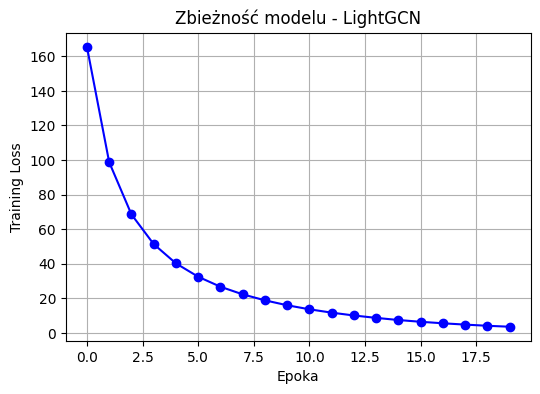

WYNIKI OGÓLNE LightGCN
   recall@5  recall@10  recall@20  ndcg@5  ndcg@10  ndcg@20
0    0.0981     0.1052     0.1128  0.0884   0.0907   0.0926


In [4]:
loss_dict = trainer.train_loss_dict
plt.figure(figsize=(6, 4))
plt.plot(list(loss_dict.keys()), list(loss_dict.values()), marker='o', color='blue')
plt.title('Zbieżność modelu - LightGCN')
plt.xlabel('Epoka')
plt.ylabel('Training Loss')
plt.grid(True)
plt.show()

print(f"WYNIKI OGÓLNE LightGCN\n{test_result}")

In [ ]:
# Zliczamy, ile razy każdy produkt wystąpił w treningu
train_items = dataset.inter_feat['item_id'].numpy()
item_popularity = pd.Series(train_items).value_counts()

# Zbieramy testowych użytkowników (bezpieczna pętla)
test_users = []
for batch in test_data:
    test_users.extend(batch[0]['user_id'].numpy())
test_users = np.unique(test_users)

# Model poleca Top-10 dla każdego

batch_size = 500  
all_topk_iid = []
device = config['device']

print(f"Przetwarzanie {len(test_users)} użytkowników w batchach po {batch_size}...")

model.eval()
with torch.no_grad():
    for i in range(0, len(test_users), batch_size):
        batch_users = test_users[i : i + batch_size]
        
        # Liczymy Top-K tylko dla małej grupy użytkowników
        _, topk_iid = full_sort_topk(
            uid_series=batch_users, 
            model=model, 
            test_data=test_data, 
            k=10, 
            device=device
        )
        
        all_topk_iid.append(topk_iid.cpu())
        
        if i % 5000 == 0:
            print(f"Skończono: {i}/{len(test_users)}")

# Łączymy wyniki w jedną macierz
topk_iid = torch.cat(all_topk_iid, dim=0)
recommended_items = topk_iid.numpy().flatten()

recommended_items = topk_iid.cpu().numpy().flatten()

# Przypisujemy poleconym produktom ich historyczną popularność
rec_popularity = item_popularity.loc[recommended_items].fillna(0).values

Przetwarzanie 48433 użytkowników w batchach po 500...
Skończono: 0/48433
Skończono: 5000/48433
Skończono: 10000/48433
Skończono: 15000/48433
Skończono: 20000/48433
Skończono: 25000/48433
Skończono: 30000/48433
Skończono: 35000/48433
Skończono: 40000/48433
Skończono: 45000/48433


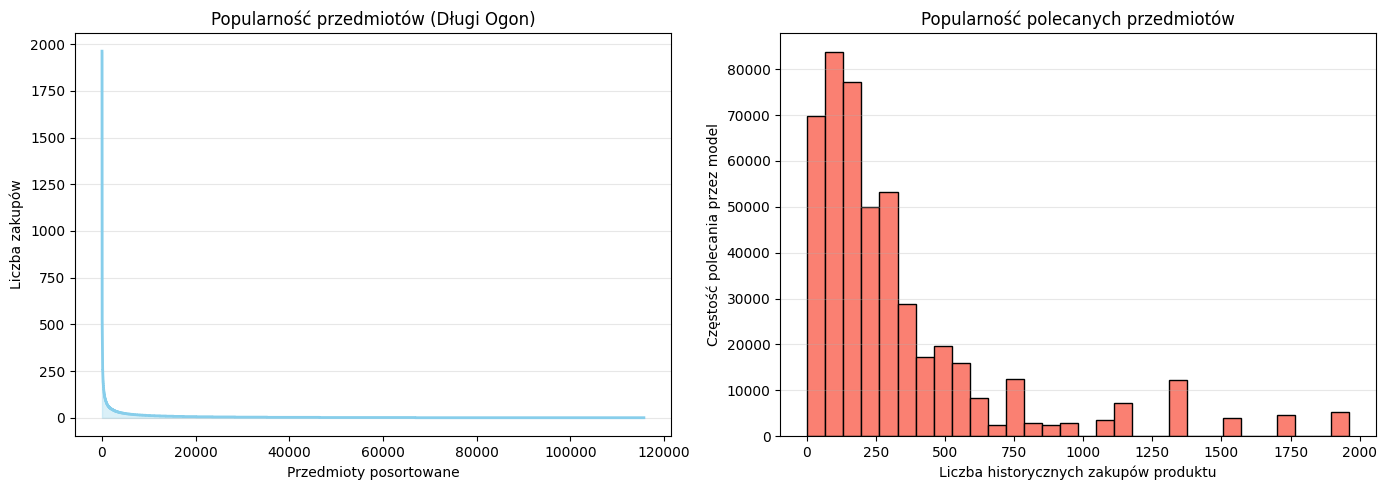


Średnia popularność polecanego produktu: 338.39


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Długi Ogon (Popularność ogólna)
axes[0].plot(item_popularity.values, color='skyblue', linewidth=2)
axes[0].fill_between(range(len(item_popularity)), item_popularity.values, color='skyblue', alpha=0.3)
axes[0].set(title='Popularność przedmiotów (Długi Ogon)', xlabel='Przedmioty posortowane', ylabel='Liczba zakupów')
axes[0].grid(axis='y', alpha=0.3)

# Wykres 2: Efekt Mateusza (Co poleca model)
axes[1].hist(rec_popularity, bins=30, color='salmon', edgecolor='black')
axes[1].set(title='Popularność polecanych przedmiotów', xlabel='Liczba historycznych zakupów produktu', ylabel='Częstość polecania przez model')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nŚrednia popularność polecanego produktu: {np.mean(rec_popularity):.2f}")

### Zadanie 2 - Wnioski i Analiza Popularności (LightGCN)

**1. Trening i Ewaluacja:**
Wykres zbieżności potwierdza prawidłowe uczenie się modelu (strata gładko spada do zera). Osiągnięte wyniki (m.in. Recall@20 = 0.1128, NDCG@20 = 0.0926)
**2. Długi Ogon (Long Tail):**
Zbiór treningowy wykazuje silne zjawisko długiego ogona (lewy wykres). Zdecydowaną większość interakcji generuje bardzo mała liczba bestsellerów, podczas gdy reszta obszernego katalogu to produkty o znikomej popularności.

**3. Efekt Mateusza (Matthew Effect):**
W systemach rekomendacyjnych objawia się on tendencją do promowania przedmiotów już popularnych ("bogaty staje się bogatszy"). 
* Średnia popularność rekomendowanego produktu jest wysoka (ok. 338 historycznych zakupów).
* Na prawym histogramie widoczne są wyraźne piki dla produktów o bardzo wysokiej popularności (nawet powyżej 1250-1750 zakupów). 
* Algorytm LightGCN, opierając się na strukturze grafu, siłą rzeczy przypisuje większą wagę gęsto połączonym węzłom. 
* Powoduje to sprzężenie zwrotne: hity sprzedażowe stają się jeszcze popularniejsze dzięki częstym rekomendacjom, co ogranicza widoczność niszowych marek (tzw. *popularity bias*).